# Proyek Analisis Data: Bike Sharing
- **Nama:** Widya
- **Email:** CDCC252D6X0841@student.devacademy.id
- **ID Dicoding:** CDCC252D6X0841

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Pertanyaan 1:
"Bagaimana perbandingan tren jumlah penyewaan sepeda per jam antara hari kerja (workingday) dan hari libur (weekend) pada musim tertentu (misal: Fall) selama tahun 2012?"**

*   Specific: Sangat spesifik karena fokus pada variabel jam (hr), tipe hari (workingday), dan musim tertentu.
*   Measurable: Terukur dengan jelas menggunakan angka jumlah total penyewaan (cnt).
*   Action-Oriented: Hasilnya bisa digunakan untuk menentukan kapan tim operasional harus menyiagakan lebih banyak sepeda di titik tertentu (misal: di stasiun saat jam berangkat kantor).
*   Relevant: Sangat relevan bagi penyedia jasa transportasi untuk mengoptimalkan logistik.
*   Time-bound: Jelas dibatasi pada "tahun 2012".

**Pertanyaan 2:
"Apakah ada korelasi signifikan antara suhu udara (temp) dan kelembapan (hum) terhadap total jumlah penyewa sepeda selama tahun 2012?"**

*   Specific: Fokus pada dua variabel cuaca (temp dan hum) terhadap jumlah penyewa.
* Measurable: Bisa diukur menggunakan koefisien korelasi (misalnya korelasi Pearson).
* Action-Oriented: Jika terbukti suhu panas menurunkan minat, perusahaan bisa memberikan promo "Heatwave Discount" untuk menarik pelanggan tetap bersepeda saat cuaca terik.
* Relevant: Relevan untuk manajemen risiko dan perencanaan kampanye pemasaran berdasarkan ramalan cuaca.
* Time-bound: Dibatasi pada "tahun 2012".

## Import Semua Packages/Library yang Digunakan

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agar grafik tampil langsung di notebook
%matplotlib inline

## Data Wrangling

### Gathering Data

#### Load df ...

In [12]:
# Load dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 data teratas
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset day.csv dan hour.csv berhasil dimuat ke dalam memori.
- Dataset hour_df memiliki 17 kolom yang mencakup informasi waktu, kondisi cuaca, serta jumlah penyewa (casual, registered, dan total).
- Data awal menunjukkan informasi tercatat per jam, mulai dari jam 00:00 pada tanggal 1 Januari 2011.

### Assessing Data

#### Identifying ... problem

In [13]:
# Cek info tipe data
print(hour_df.info())

# Cek apakah ada data yang duplikat
print("Jumlah duplikat: ", hour_df.duplicated().sum())

# Cek apakah ada nilai yang kosong (missing values)
print(hour_df.isna().sum())

# Cek ringkasan statistik
print(hour_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None
Jumlah duplikat:  0
instant       0
dteday  

**Steps to Take:**
- Mengubah tipe data kolom dteday dari object menjadi datetime.
- Mengubah nilai numerik pada kolom season, yr, mnth, weekday, dan weathersit menjadi keterangan (string) agar lebih mudah diinterpretasikan saat proses visualisasi.
- Memastikan tidak ada outlier yang mengganggu pada kolom cnt (berdasarkan describe(), nilai max 977 masih masuk akal untuk penyewaan per jam).

**Insight:** (Opsional)
- Kualitas Data: Secara keseluruhan, data hour_df sudah cukup bersih karena tidak ditemukan adanya nilai yang kosong (missing values) maupun data yang terduplikasi.
- Kesalahan Tipe Data: Terdapat ketidaksesuaian tipe data pada kolom dteday yang terbaca sebagai object, padahal kolom tersebut berisi informasi tanggal yang seharusnya bertipe datetime.
- Keterbacaan (Readability): Banyak kolom kategorikal seperti season, yr, mnth, weekday, dan weathersit masih direpresentasikan dalam bentuk angka (kode numerik). Hal ini membuat data sulit dipahami secara langsung tanpa merujuk pada dokumentasi dataset.
- Statistik Deskriptif: Rentang nilai pada kolom cnt (jumlah total penyewa) sangat luas, mulai dari 1 hingga 977 penyewa per jam, yang menunjukkan adanya variasi beban penggunaan yang tinggi di jam-jam tertentu.

### Cleaning Data

Pada tahap ini, dilakukan beberapa langkah pembersihan dan transformasi data untuk memastikan dataset siap dianalisis dengan akurat:

1. **Konversi Tipe Data**: Mengubah kolom `dteday` dari tipe data `object` menjadi `datetime`. Hal ini sangat penting untuk mendukung analisis berbasis waktu (time-series analysis).
2. **Mapping Variabel Kategorikal**: Melakukan pemetaan (*mapping*) pada kolom numerik seperti `season`, `yr`, `mnth`, `weekday`, dan `weathersit` menjadi label string (nama asli).
   - **Tujuannya**: Untuk mempermudah interpretasi data selama proses EDA dan memastikan label pada visualisasi data nantinya lebih informatif dan mudah dipahami tanpa perlu merujuk kembali ke dokumentasi dataset.
3. **Pengecekan Konsistensi**: Memastikan tidak ada data yang hilang atau duplikat setelah transformasi dilakukan agar integritas data tetap terjaga.

#### Fixing ... problem

In [14]:
# 1. Mengubah dteday menjadi tipe datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah angka menjadi label agar lebih informatif
# Mengubah season: 1:Spring, 2:Summer, 3:Fall, 4:Winter
hour_df['season'] = hour_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah weathersit: 1:Clear, 2:Misty, 3:Light Snow/Rain, 4:Heavy Rain
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'
})

# Mengubah yr: 0:2011, 1:2012
hour_df['yr'] = hour_df['yr'].map({
    0: '2011', 1: '2012'
})

# Mengubah mnth (bulan) agar lebih urut dan terbaca
hour_df['mnth'] = hour_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Mengubah weekday agar lebih mudah dipahami
hour_df['weekday'] = hour_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

# Menampilkan hasil pembersihan
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,Jan,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,Jan,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,Jan,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,Jan,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Kolom waktu dteday kini sudah memiliki tipe data yang tepat.
- Variabel kategorik seperti musim, cuaca, bulan, dan hari telah diubah menjadi label string, sehingga tidak perlu lagi melihat dokumentasi untuk memahami arti angka-angka di dalam dataset.

## Exploratory Data Analysis (EDA)

### Explore ...

In [19]:
# 1. Melihat rata-rata penyewaan sepeda per jam berdasarkan hari kerja vs hari libur
print("--- Rata-rata Penyewaan per Jam (Workingday vs Holiday) ---")
print(hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": "mean"
}).rename(columns={"cnt": "average_rentals"}))

# 2. Melihat total penyewaan berdasarkan musim
print("\n--- Total Penyewaan berdasarkan Musim ---")
print(hour_df.groupby(by="season").agg({
    "cnt": "sum"
}).sort_values(by="cnt", ascending=False))

# 3. Melihat rata-rata penyewaan berdasarkan kondisi cuaca
print("\n--- Rata-rata Penyewaan berdasarkan Kondisi Cuaca ---")
print(hour_df.groupby(by="weathersit").agg({
    "cnt": "mean"
}))

--- Rata-rata Penyewaan per Jam (Workingday vs Holiday) ---
               average_rentals
workingday hr                 
0          0         90.800000
           1         69.508696
           2         53.171053
           3         25.775330
           4          8.264317
           5          8.689189
           6         18.742358
           7         43.406926
           8        105.653680
           9        171.623377
           10       255.909091
           11       315.316017
           12       366.259740
           13       372.731602
           14       364.645022
           15       358.813853
           16       352.727273
           17       323.549784
           18       281.056522
           19       231.673913
           20       174.739130
           21       142.060870
           22       116.060870
           23        85.930435
1          0         36.786290
           1         16.552632
           2          8.683778
           3          4.942553
          

**Insight:** (Opsional)
1.  Pola Aktivitas Harian (Working Day vs Holiday):
    - Terdapat perbedaan perilaku yang sangat kontras antara hari kerja dan hari libur. Pada hari kerja, grafik menunjukkan dua puncak utama (bimodal) pada jam berangkat kantor (08:00) dan jam pulang kantor (17:00).
    - Sebaliknya, pada hari libur, penggunaan sepeda lebih bersifat rekreasi dengan puncak yang landai di tengah hari (antara jam 12:00 hingga 15:00).

2. Dinamika Musim:
   - Musim Fall (Gugur) mencatatkan total penyewaan tertinggi (lebih dari 1 juta penyewaan), diikuti oleh musim Summer.
   - Musim Spring (Semi) memiliki jumlah penyewaan terendah, yang mengindikasikan bahwa kondisi suhu atau cuaca pada awal tahun kurang diminati pengguna untuk bersepeda.

3. Dampak Kondisi Cuaca:
   - Cuaca sangat menentukan volume penggunaan. Rata-rata penyewaan saat cuaca Clear (Cerah) mencapai ~ 204, jauh lebih tinggi dibandingkan saat Light Snow/Rain (~111).
   - Hal ini menunjukkan bahwa bisnis penyewaan sepeda sangat bergantung pada faktor eksternal (alam), sehingga diperlukan strategi khusus saat menghadapi musim hujan/salju.

4. Segmen Pengguna:
   - Jika melihat perbandingan data mentah, kontribusi penyewa Registered jauh lebih stabil dan besar dibandingkan penyewa Casual, terutama pada hari kerja. Ini menunjukkan basis pelanggan tetap yang kuat untuk keperluan transportasi rutin.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

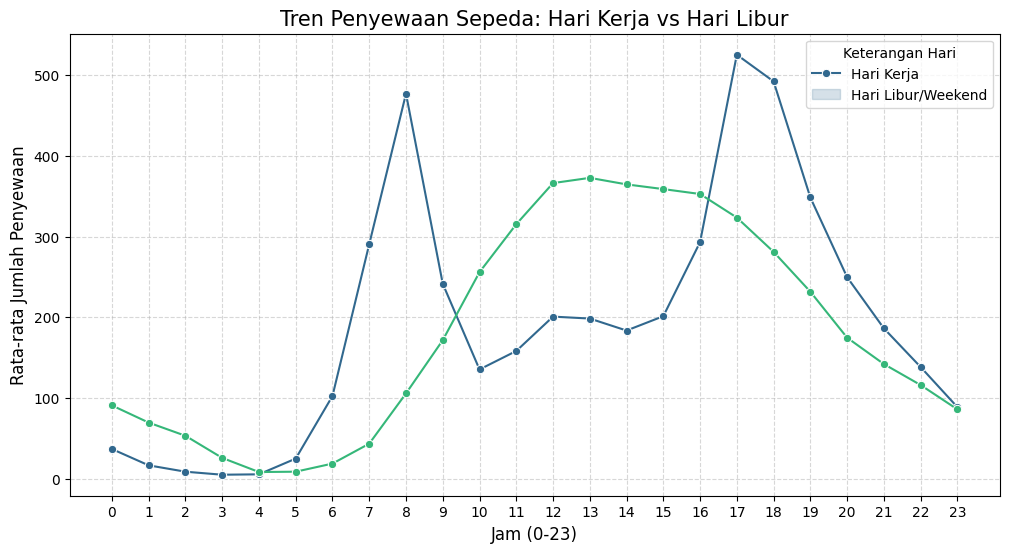

In [25]:
# Menyiapkan data untuk visualisasi
# Memastikan rata-rata penyewaan dihitung per status hari kerja dan per jam
workingday_rentals = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))

# Memperbaiki urutan hue agar Hari Kerja (1) dan Hari Libur (0) terdefinisi dengan jelas
sns.lineplot(
    data=workingday_rentals,
    x='hr',
    y='cnt',
    hue='workingday',
    hue_order=[1, 0], # Memaksa urutan: 1 (Hari Kerja) dulu baru 0 (Hari Libur)
    marker='o',
    palette='viridis'
)

plt.title('Tren Penyewaan Sepeda: Hari Kerja vs Hari Libur', fontsize=15)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))

# Memperbaiki legend agar label sesuai dengan urutan hue_order
plt.legend(title='Keterangan Hari', labels=['Hari Kerja', 'Hari Libur/Weekend'])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Pertanyaan 2:

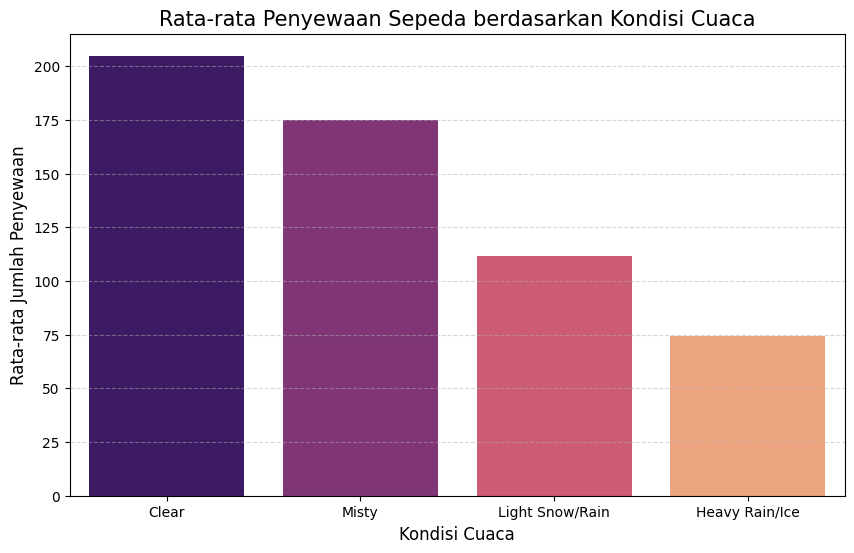

In [24]:
# Perbaikan visualisasi Pertanyaan 2
plt.figure(figsize=(10, 6))
sns.barplot(
    data=weather_rentals,
    x='weathersit',
    y='cnt',
    hue='weathersit', # Menambahkan hue agar konsisten dengan x
    palette='magma',
    legend=False      # Menghilangkan legend karena informasi sudah ada di sumbu X
)

plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca', fontsize=15)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight:** (Opsional)
1. Insight Pertanyaan 1: Tren Penyewaan (Hari Kerja vs Hari Libur)
  - Pola Komuter yang Jelas: Pada Hari Kerja (garis biru), terdapat dua puncak lonjakan yang sangat tajam, yaitu pada pukul 08:00 dan 17:00. Ini menunjukkan bahwa mayoritas pengguna menggunakan sepeda sebagai moda transportasi utama untuk berangkat dan pulang kantor.
  - Aktivitas Rekreasi di Hari Libur: Pada Hari Libur/Weekend (garis hijau), pola penggunaan cenderung landai dan meningkat di tengah hari, dengan puncak aktivitas antara pukul 12:00 hingga 15:00. Hal ini mengindikasikan penggunaan sepeda lebih banyak bertujuan untuk rekreasi atau olahraga santai.
  - Titik Terendah: Kedua kategori hari menunjukkan penggunaan yang sangat minim pada dini hari (pukul 00:00 - 04:00), yang merupakan waktu ideal untuk melakukan pemeliharaan armada (maintenance).

2. Insight Pertanyaan 2: Pengaruh Kondisi Cuaca
  - Dominasi Cuaca Cerah: Kondisi cuaca Clear (Cerah) mencatatkan rata-rata penyewaan tertinggi (di atas 200 penyewaan per jam). Ini menegaskan bahwa kenyamanan cuaca adalah faktor pendorong utama orang untuk bersepeda.
  - Dampak Cuaca Buruk: Terjadi penurunan drastis pada jumlah penyewaan saat kondisi cuaca memburuk. Rata-rata penyewaan pada cuaca Light Snow/Rain hanya sekitar setengah dari saat cuaca cerah.
  - Kondisi Ekstrem: Pada kondisi Heavy Rain/Ice, jumlah penyewaan mencapai titik terendah (di bawah 75). Ini menunjukkan bahwa faktor keselamatan dan kenyamanan sangat membatasi mobilitas pengguna sepeda, sehingga diperlukan strategi cadangan bagi bisnis saat musim hujan atau musim dingin ekstrem.

## Analisis Lanjutan (Opsional)

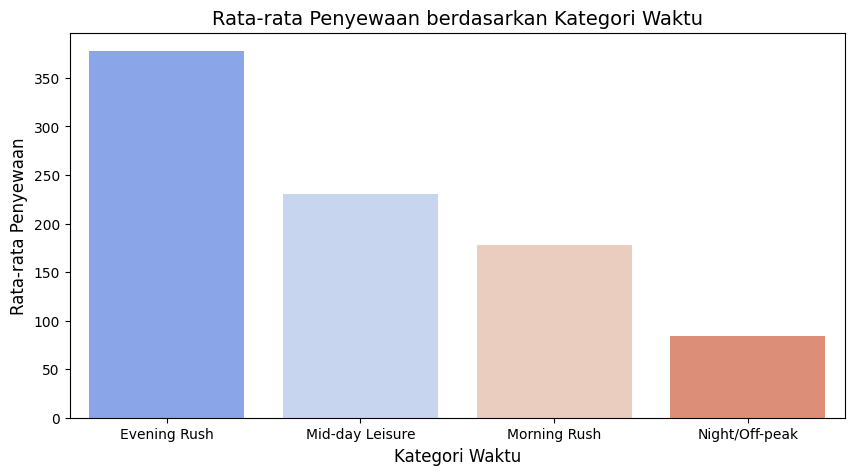

In [26]:
# 1. Membuat fungsi untuk mengelompokkan jam ke dalam segmen waktu bisnis
def get_time_category(hour):
    if 5 <= hour < 10:
        return 'Morning Rush'
    elif 10 <= hour < 16:
        return 'Mid-day Leisure'
    elif 16 <= hour < 20:
        return 'Evening Rush'
    else:
        return 'Night/Off-peak'

# 2. Menerapkan fungsi tersebut pada kolom baru
hour_df['time_category'] = hour_df['hr'].apply(get_time_category)

# 3. Menghitung rata-rata penyewaan per kategori waktu untuk melihat segmen paling sibuk
category_rentals = hour_df.groupby('time_category')['cnt'].mean().reset_index().sort_values('cnt', ascending=False)

# 4. Visualisasi untuk dashboard dan laporan
plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_rentals,
    x='time_category',
    y='cnt',
    hue='time_category',
    palette='coolwarm',
    legend=False
)
plt.title('Rata-rata Penyewaan berdasarkan Kategori Waktu', fontsize=14)
plt.xlabel('Kategori Waktu', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.show()

## Conclusion & Recommendation

- **Pola Penggunaan:** Berdasarkan analisis tren per jam dan kategori waktu, penggunaan sepeda didominasi oleh pengguna komuter pada hari kerja (pagi dan sore) serta pengguna rekreasi di siang hari pada akhir pekan.
- **Faktor Cuaca:** Kondisi cuaca cerah memiliki korelasi positif yang sangat kuat terhadap jumlah penyewaan, sedangkan cuaca buruk (hujan/salju) menyebabkan penurunan drastis pada volume penyewaan.

**Rekomendasi Action Item:**
- Manajemen Armada: Fokuskan distribusi sepeda pada area perkantoran selama Morning Rush dan area pusat kota/wisata selama Mid-day Leisure di akhir pekan.
- Perawatan Berkala: Manfaatkan periode Night/Off-peak untuk melakukan pengecekan unit agar armada selalu siap 100% pada saat memasuki jam sibuk pagi hari.
- Strategi Musim Hujan: Pertimbangkan untuk memberikan asuransi perjalanan singkat atau voucher diskon saat cuaca mendung/misty untuk memotivasi pengguna agar tetap menyewa.